In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
# ========== 1. 讀取資料 ==========
df = pd.read_csv("student_depression_dataset.csv")
df = df.drop("City", axis=1)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.info(),df.head())

Shape: (27901, 17)
Columns: ['id', 'Gender', 'Age', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA       

None

,id,Gender,Age,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
df.describe().style.format("{:.2f}")

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00,27901.00
mean,70442.15,25.82,3.14,0.00,7.66,2.94,0.00,7.16,0.59
std,40641.18,4.91,1.38,0.04,1.47,1.36,0.04,3.71,0.49
min,2.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35039.00,21.00,2.00,0.00,6.29,2.00,0.00,4.00,0.00
50%,70684.00,25.00,3.00,0.00,7.77,3.00,0.00,8.00,1.00
75%,105818.00,30.00,4.00,0.00,8.92,4.00,0.00,10.00,1.00
max,140699.00,59.00,5.00,5.00,10.00,5.00,4.00,12.00,1.00


/var/folders/zq/mxgrj0l10gsbm92wwv2lk1cm0000gn/T/ipykernel_46454/2451443980.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Depression", data=df, palette="Set2")


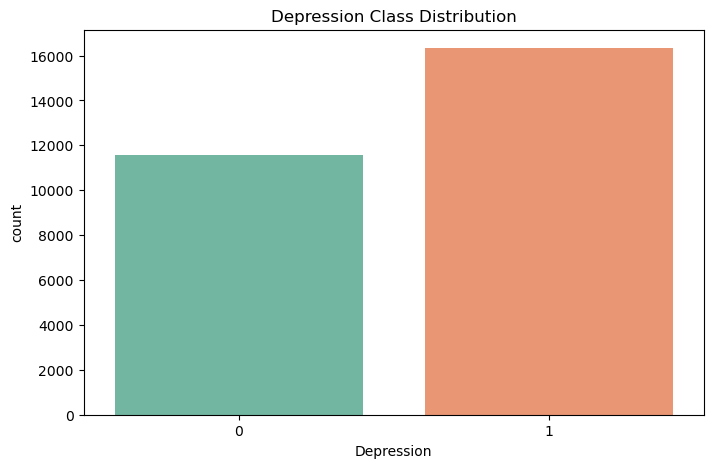

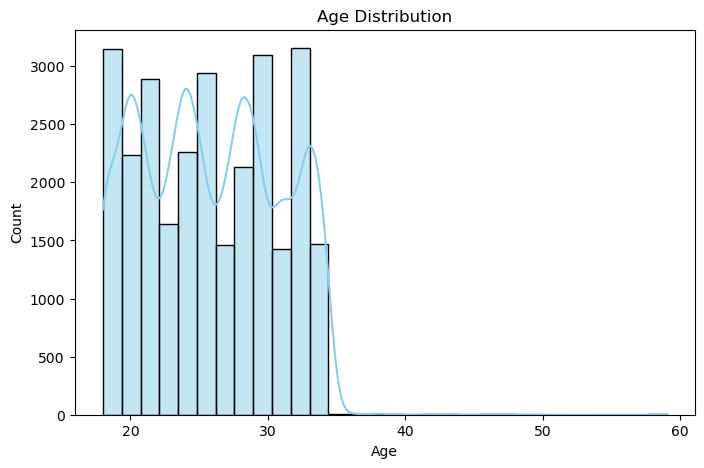

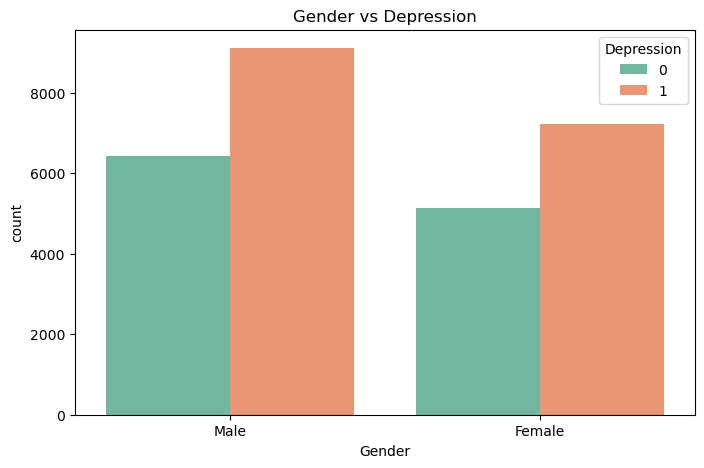

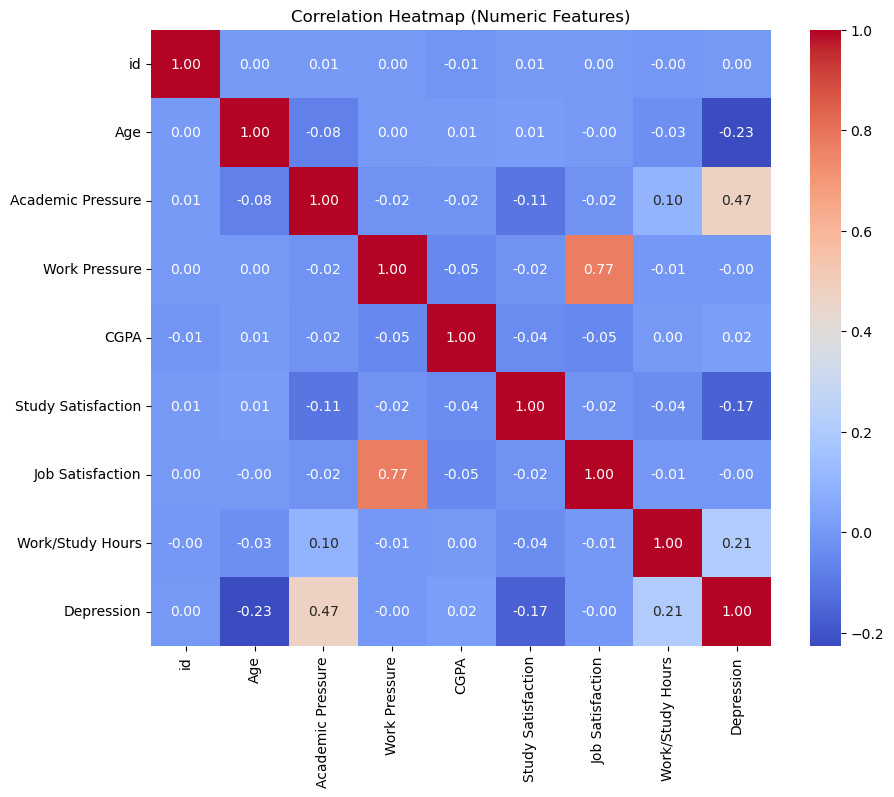

In [4]:
# 目標變數分佈
plt.figure(figsize=(8,5))
sns.countplot(x="Depression", data=df, palette="Set2")
plt.title("Depression Class Distribution")
plt.show()

# 年齡分佈
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True, color="skyblue")
plt.title("Age Distribution")
plt.show()

# 性別 vs 抑鬱
plt.figure(figsize=(8,5))
sns.countplot(x="Gender", hue="Depression", data=df, palette="Set2")
plt.title("Gender vs Depression")
plt.show()

# 數值型欄位相關性
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [17]:
# ========== 3. 資料前處理 ==========
target_col = "Depression"

# 分類欄位（需做 OneHotEncoding）
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical features:", categorical_cols)

# 數值欄位
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("id")
numeric_cols.remove(target_col)

# 前處理：數值做 RobustScaler，類別做 OneHot
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# 切分資料
X = df.drop(columns=[target_col, "id"])  # 去掉id
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Categorical features: ['Gender', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']


In [19]:
# ========== 4. 模型建立 ==========
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver="liblinear", random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42),
    "K Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, n_jobs=-1
    )
}

results = []
roc_curves = {}
pr_curves  = {}

def get_score(model, X_test):
    """統一輸出模型預測分數"""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)[:,1]
    else:
        return model.decision_function(X_test)

for name, clf in models.items():
    pipe = Pipeline(steps=[("pre", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_score = get_score(pipe, X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_score)
    pr_auc  = average_precision_score(y_test, y_score)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    prec, rec_curve, _ = precision_recall_curve(y_test, y_score)

    roc_curves[name] = (fpr, tpr, roc_auc)
    pr_curves[name]  = (prec, rec_curve, pr_auc)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc
    })

res_df = pd.DataFrame(results).sort_values("ROC AUC", ascending=False)
print("\n=== Model Performance ===")
print(res_df.to_string(index=False, float_format="%.3f"))


=== Model Performance ===
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC  PR AUC
   Logistic Regression     0.845      0.859   0.881     0.870    0.918   0.937
               XGBoost     0.845      0.858   0.881     0.869    0.918   0.936
         Random Forest     0.837      0.849   0.879     0.864    0.914   0.934
Support Vector Machine     0.842      0.848   0.889     0.868    0.913   0.925
   K Nearest Neighbors     0.820      0.822   0.883     0.852    0.885   0.889


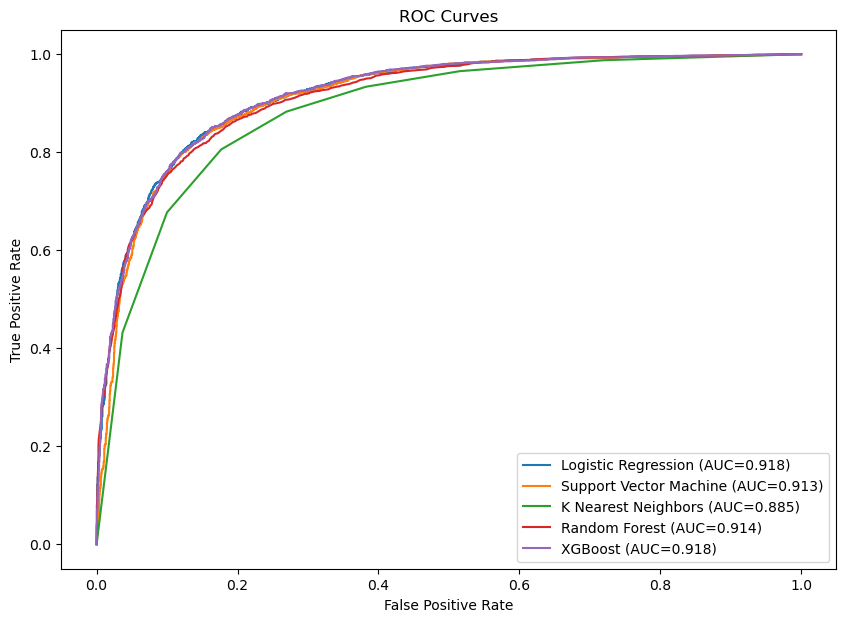

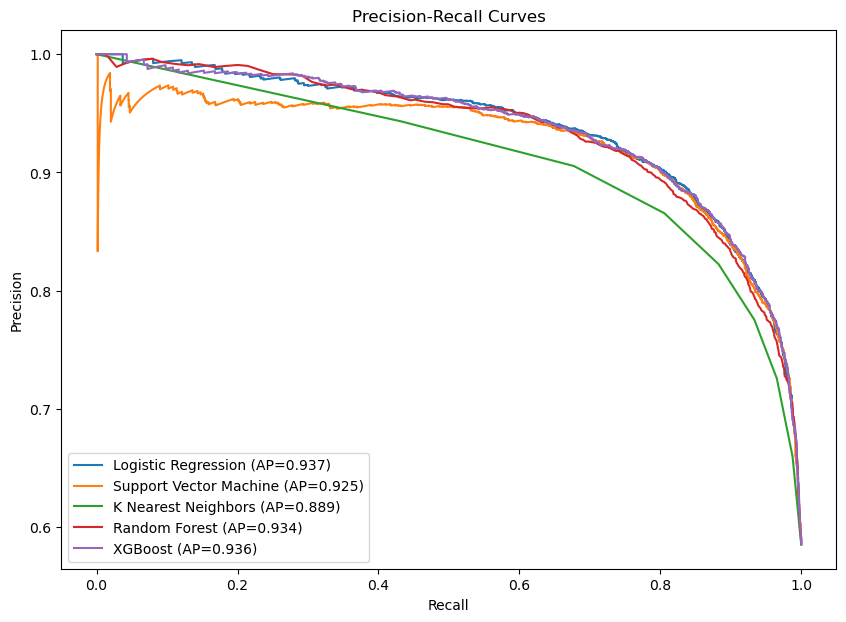

In [20]:
# ========== 5. ROC & PRC 圖 ==========
plt.figure(figsize=(10,7))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
#plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

plt.figure(figsize=(10,7))
for name, (prec, rec_curve, ap) in pr_curves.items():
    plt.plot(rec_curve, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

In [21]:
# =========================
# Hyperparameter tuning: Logistic Regression & XGBoost
# =========================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- 1) Logistic Regression 調參 ----
logreg = LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)
logreg_params = {
    "penalty": ["l1", "l2"],
    "C": np.logspace(-3, 2, 10)  # C 越小正則化越強
}

logreg_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[("pre", preprocessor), ("clf", logreg)]),
    param_distributions={"clf__" + k: v for k, v in logreg_params.items()},
    n_iter=15, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=42, verbose=1
)
logreg_search.fit(X_train, y_train)

best_logreg = logreg_search.best_estimator_
print("\n✅ Logistic Regression Best Params:", logreg_search.best_params_)
print(f"CV Best ROC AUC: {logreg_search.best_score_:.3f}")

# ---- 2) XGBoost 調參 ----
xgb = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss",
    random_state=42, n_jobs=-1, tree_method="hist"
)
xgb_params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "reg_lambda": [0.1, 1, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[("pre", preprocessor), ("clf", xgb)]),
    param_distributions={"clf__" + k: v for k, v in xgb_params.items()},
    n_iter=25, scoring="roc_auc", cv=cv, n_jobs=-1, random_state=42, verbose=1
)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print("\n✅ XGBoost Best Params:", xgb_search.best_params_)
print(f"CV Best ROC AUC: {xgb_search.best_score_:.3f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

✅ Logistic Regression Best Params: {'clf__penalty': 'l1', 'clf__C': 0.1668100537200059}
CV Best ROC AUC: 0.922
Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ XGBoost Best Params: {'clf__subsample': 0.8, 'clf__reg_lambda': 1, 'clf__n_estimators': 200, 'clf__min_child_weight': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}
CV Best ROC AUC: 0.921



📌 Logistic Regression Top-10 Coefficients (abs)
                                           Feature  Importance
1                           num__Academic Pressure    1.676159
59   cat__Have you ever had suicidal thoughts ?_No    1.267862
60  cat__Have you ever had suicidal thoughts ?_Yes    1.214350
61                       cat__Financial Stress_1.0    1.127458
65                       cat__Financial Stress_5.0    1.088050
0                                         num__Age    1.046731
62                       cat__Financial Stress_2.0    0.702109
6                            num__Work/Study Hours    0.696332
30                   cat__Dietary Habits_Unhealthy    0.584443
27                     cat__Dietary Habits_Healthy    0.478962


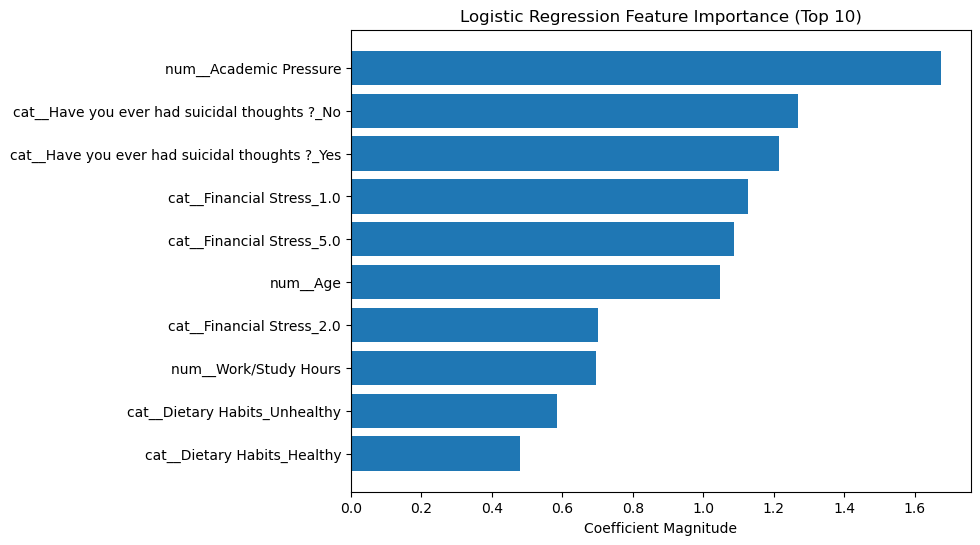


📌 XGBoost Top-10 Feature Importance
                                           Feature  Importance
60  cat__Have you ever had suicidal thoughts ?_Yes    0.279377
59   cat__Have you ever had suicidal thoughts ?_No    0.242559
1                           num__Academic Pressure    0.082619
63                       cat__Financial Stress_3.0    0.045720
65                       cat__Financial Stress_5.0    0.044742
64                       cat__Financial Stress_4.0    0.040938
61                       cat__Financial Stress_1.0    0.035248
30                   cat__Dietary Habits_Unhealthy    0.021703
0                                         num__Age    0.019964
62                       cat__Financial Stress_2.0    0.019201


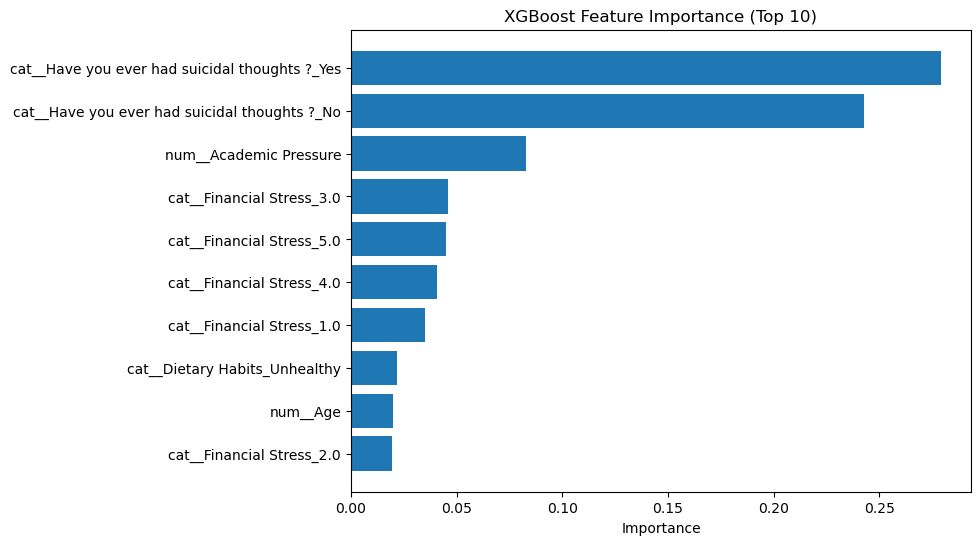

In [22]:
# ----  特徵重要性 ----
# Logistic Regression: 係數絕對值
logreg_clf = best_logreg.named_steps["clf"]
coef = logreg_clf.coef_[0]
feature_names = preprocessor.get_feature_names_out()
logreg_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(coef)
}).sort_values("Importance", ascending=False).head(10)

print("\n📌 Logistic Regression Top-10 Coefficients (abs)")
print(logreg_imp)

plt.figure(figsize=(8,6))
plt.barh(logreg_imp["Feature"][::-1], logreg_imp["Importance"][::-1])
plt.title("Logistic Regression Feature Importance (Top 10)")
plt.xlabel("Coefficient Magnitude")
plt.show()

# XGBoost: feature_importances_
xgb_clf = best_xgb.named_steps["clf"]
xgb_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_clf.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

print("\n📌 XGBoost Top-10 Feature Importance")
print(xgb_imp)

plt.figure(figsize=(8,6))
plt.barh(xgb_imp["Feature"][::-1], xgb_imp["Importance"][::-1])
plt.title("XGBoost Feature Importance (Top 10)")
plt.xlabel("Importance")
plt.show()